In [22]:
%load_ext autoreload
%autoreload 2
import helper
import plotting
import constants
from datetime import datetime
import numpy as np
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Wahl-O-Mat Agreement Score Calculation

In [ ]:
# Idea:
# Agreement score calculation idea: 
    # 1 = stimme zu, 0 = neutral, -1 = stimme nicht zu
# Calculate the following agreement scores: 
    # Government coalition parties agreement among each other
    # Opposition parties agreement among each other
    # Between all parties in the parliament
# For each Gesetzentwurf PDF, identify the relevant Wahl-O-Mat topics it addresses via LLM. 
# Then add agreement scores as case attributes in the event log.

## Berlin

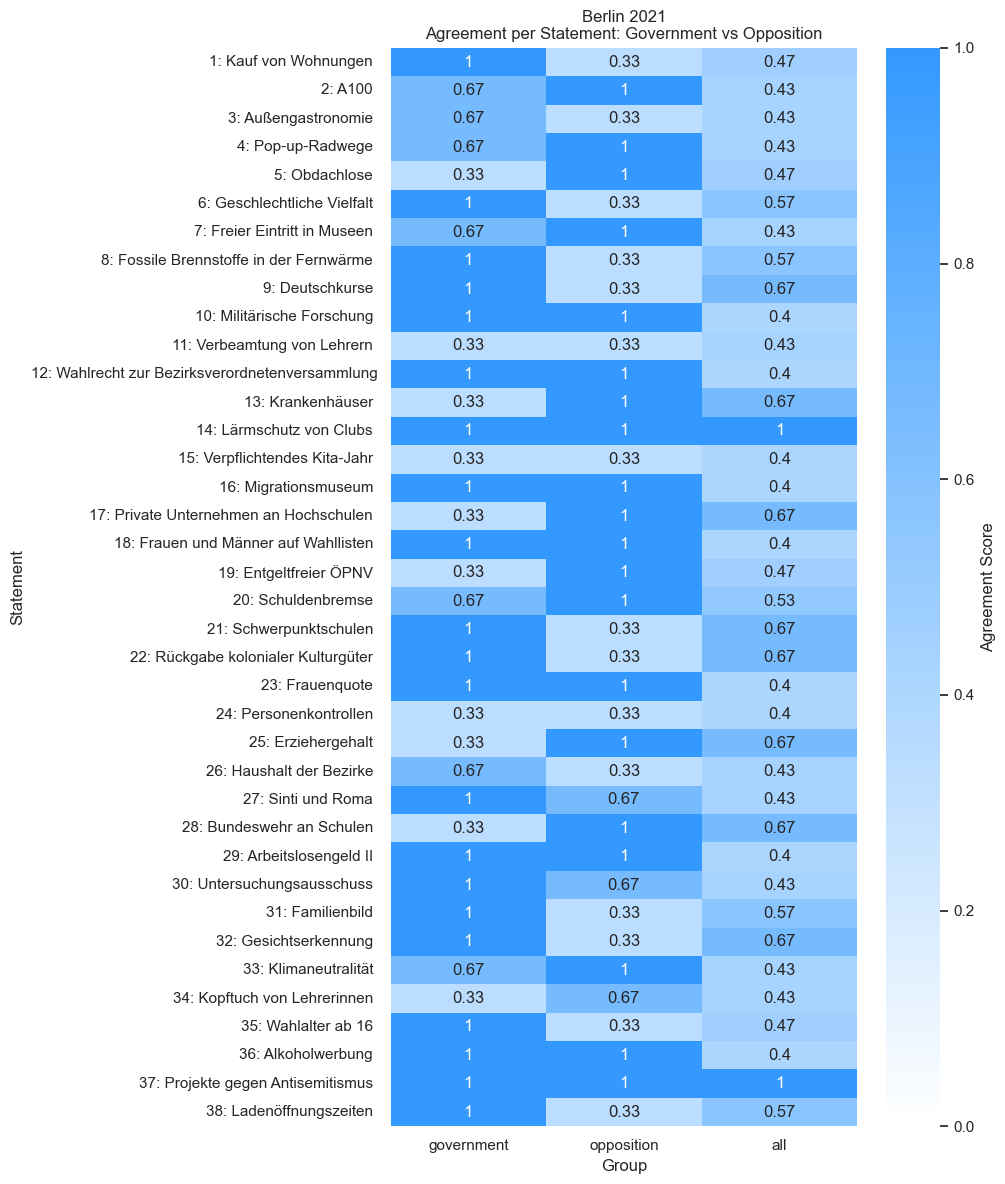

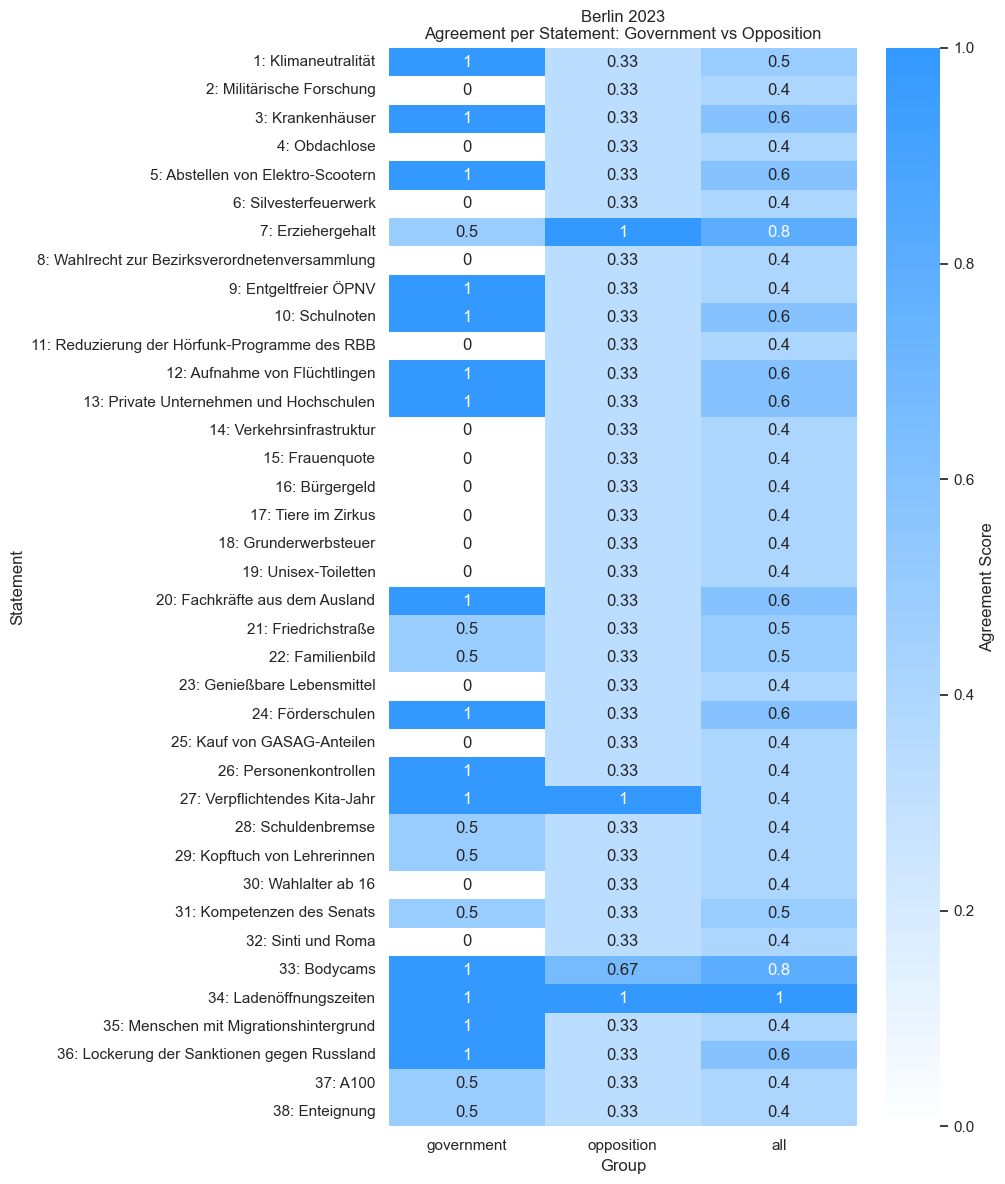

In [24]:
file_path = "./2025-03-26_Wahl-O-Mat-Datensaetze/2025-03-26-Wahl-O-Mat-Datensaetze.xlsx"

agreement_scores_berlin_2021 = helper.calculate_agreement_scores(
    file_path=file_path,
    sheet_name="BE21_v1.01",
    reference_date="01.01.2022",
    coalitions=constants.BERLIN_COALITIONS_SORTED
)

agreement_scores_berlin_2023 = helper.calculate_agreement_scores(
    file_path=file_path,
    sheet_name="BE23_v1.00",
    reference_date="01.01.2024", 
    coalitions=constants.BERLIN_COALITIONS_SORTED
)

# for projection of 2023 wahlomat to all other election periods ...
for electionPeriod in constants.BERLIN_ELECTION_PERIODS_START_DATES:
    agreement_scores_berlin_all_time = helper.calculate_agreement_scores(
        file_path=file_path,
        sheet_name="BE23_v1.00",
        reference_date=electionPeriod.strftime("%d.%m.%Y"), 
        coalitions=constants.BERLIN_COALITIONS_SORTED
    )
    agreement_scores_berlin_all_time.to_csv(f"./wahl-o-mat-agreement-scores/agreement_scores_berlin_projection_{electionPeriod.strftime('%Y-%m-%d')}.csv", index=False)


agreement_scores_berlin_2021.to_csv("./wahl-o-mat-agreement-scores/agreement_scores_berlin_2021.csv", index=False)
agreement_scores_berlin_2023.to_csv("./wahl-o-mat-agreement-scores/agreement_scores_berlin_2023.csv", index=False)

plotting.plot_agreement_scores_heat_map(agreement_scores_berlin_2021, "Berlin 2021")
plotting.plot_agreement_scores_heat_map(agreement_scores_berlin_2023, "Berlin 2023")


## Baden-Württemberg

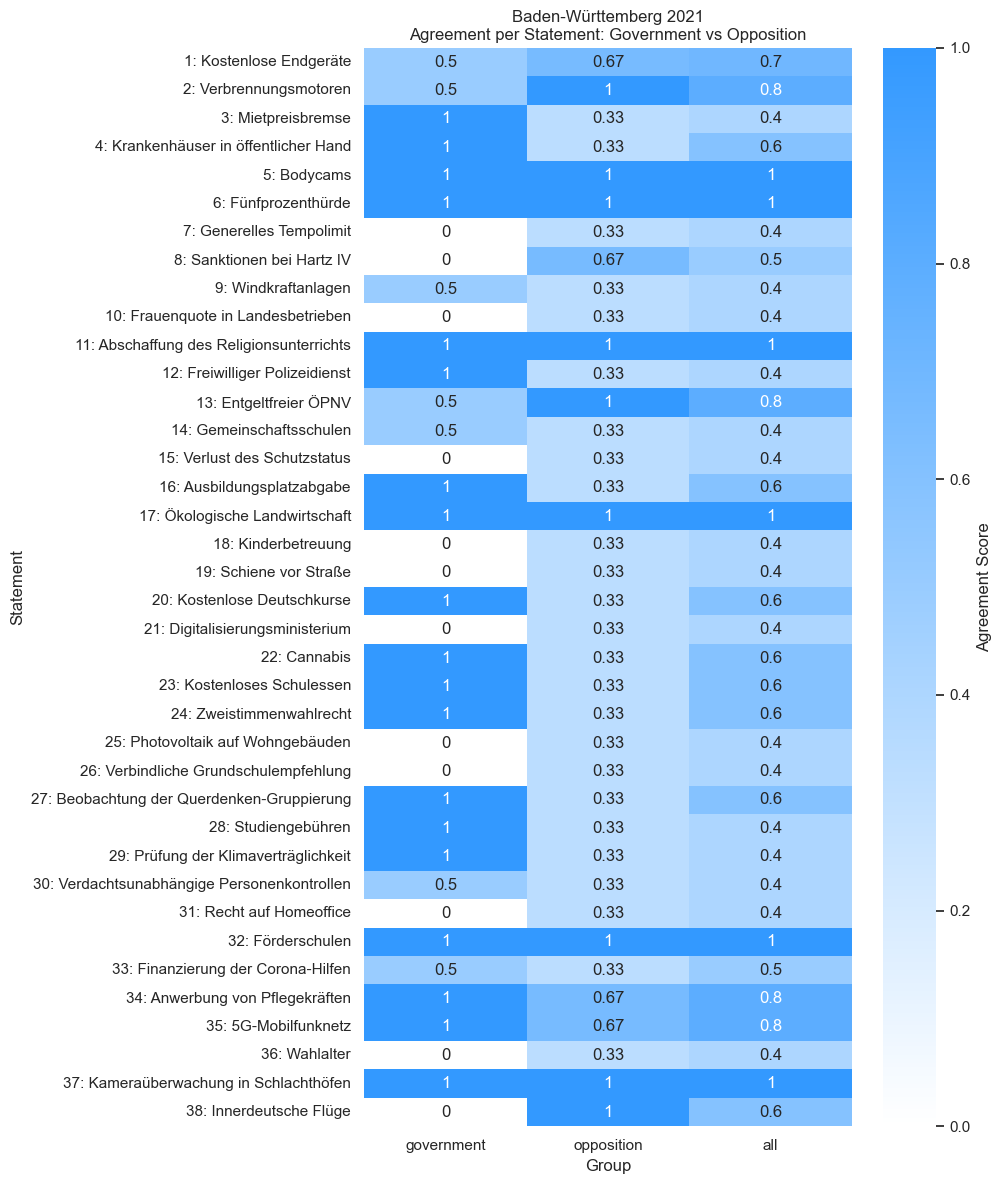

In [25]:

agreement_scores_bawue_2021 = helper.calculate_agreement_scores(
    file_path=file_path,
    sheet_name="BW21_v1.01",
    reference_date="01.01.2022", 
    coalitions=constants.BADEN_WUERTTEMBERG_COALITIONS_SORTED
)

# for projection of 2021 wahlomat to all other election periods ...
for electionPeriod in constants.BAWUE_ELECTION_PERIODS_START_DATES:
    agreement_scores_bawue_all_time = helper.calculate_agreement_scores(
        file_path=file_path,
        sheet_name="BW21_v1.01",
        reference_date=electionPeriod.strftime("%d.%m.%Y"), 
        coalitions=constants.BADEN_WUERTTEMBERG_COALITIONS_SORTED
    )
    agreement_scores_bawue_all_time.to_csv(f"./wahl-o-mat-agreement-scores/agreement_scores_bawue_projection_{electionPeriod.strftime('%Y-%m-%d')}.csv", index=False)


agreement_scores_bawue_2021.to_csv("./wahl-o-mat-agreement-scores/agreement_scores_bawue_2021.csv", index=False)

plotting.plot_agreement_scores_heat_map(agreement_scores_bawue_2021, "Baden-Württemberg 2021")

## Brandenburg

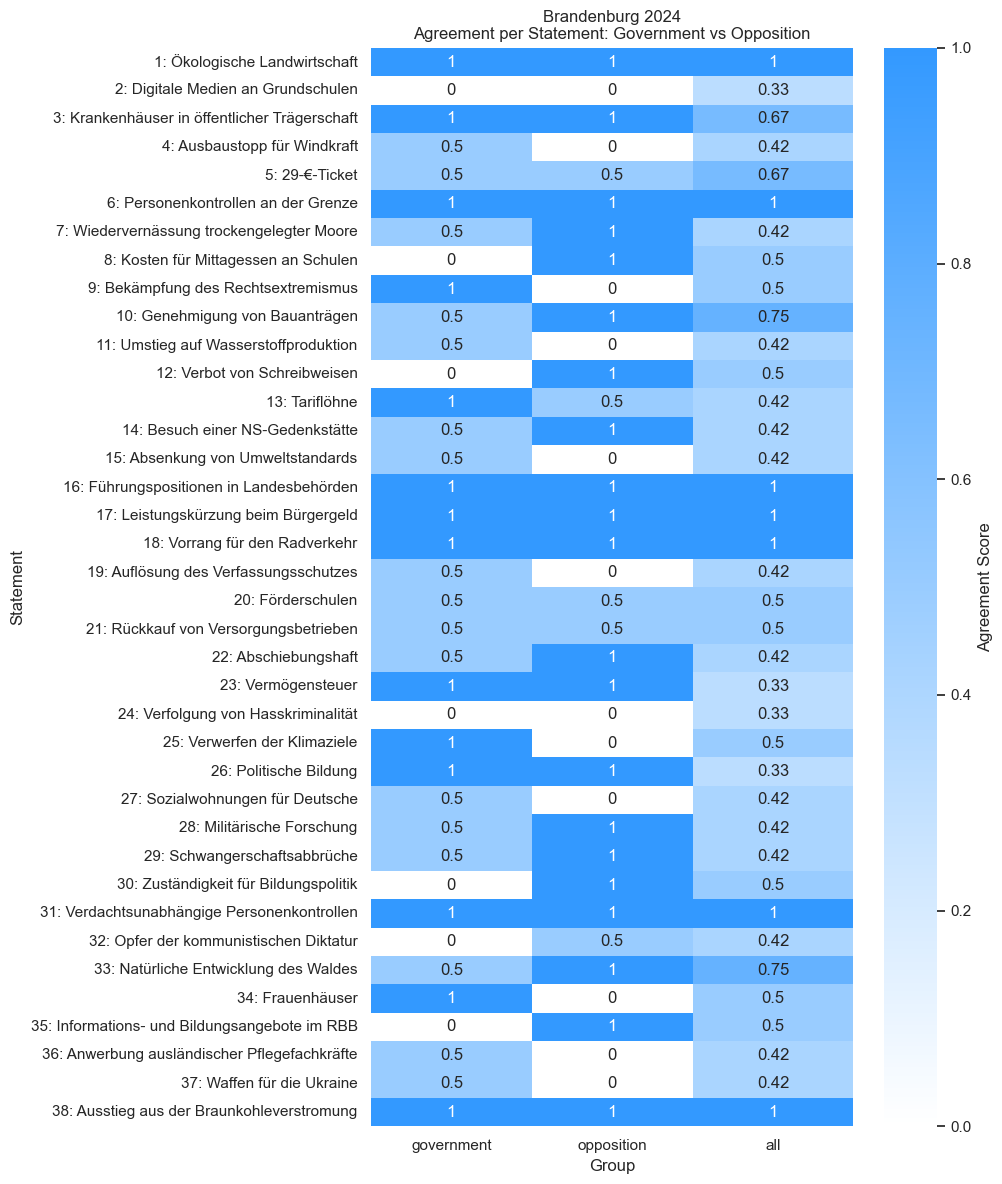

In [26]:
agreement_scores_brandenburg_2024 = helper.calculate_agreement_scores(
    file_path=file_path,
    sheet_name="BB24 v1.1",
    reference_date="17.10.2024", 
    coalitions=constants.BRANDENBURG_COALITIONS_SORTED
)

# for projection of 2021 wahlomat to all other election periods ...
for electionPeriod in constants.BRANDENBURG_ELECTION_PERIODS_START_DATES:
    agreement_scores_brandenburg_all_time = helper.calculate_agreement_scores(
        file_path=file_path,
        sheet_name="BB24 v1.1",
        reference_date=electionPeriod.strftime("%d.%m.%Y"), 
        coalitions=constants.BRANDENBURG_COALITIONS_SORTED
    )
    agreement_scores_brandenburg_all_time.to_csv(f"./wahl-o-mat-agreement-scores/agreement_scores_brandenburg_projection_{electionPeriod.strftime('%Y-%m-%d')}.csv", index=False)


agreement_scores_brandenburg_2024.to_csv("./wahl-o-mat-agreement-scores/agreement_scores_brandenburg_2024.csv", index=False)

plotting.plot_agreement_scores_heat_map(agreement_scores_brandenburg_2024, "Brandenburg 2024")

# Wahl-O-Mat Topic Embeddings

In [27]:
'''
embeddings_berlin_2021 = helper.get_topic_embeddings(file_path=file_path, sheet_name="BE21_v1.01")
embeddings_berlin_2021.to_csv("./wahl-o-mat-topic-embeddings/topic-embeddings-berlin-2021.csv", index=False)
embeddings_berlin_2023 = helper.get_topic_embeddings(file_path=file_path, sheet_name="BE23_v1.00")
embeddings_berlin_2023.to_csv("./wahl-o-mat-topic-embeddings/topic-embeddings-berlin-2023.csv", index=False)

embeddings_bawue_2021 = helper.get_topic_embeddings(file_path=file_path, sheet_name="BW21_v1.01")
embeddings_bawue_2021.to_csv("./wahl-o-mat-topic-embeddings/topic-embeddings-bawue-2021.csv", index=False)
'''
embeddings_brandenburg_2024 = helper.get_topic_embeddings(file_path=file_path, sheet_name="BB24 v1.1")
embeddings_brandenburg_2024.to_csv("./wahl-o-mat-topic-embeddings/topic-embeddings-brandenburg-2024.csv", index=False)



KeyboardInterrupt: 

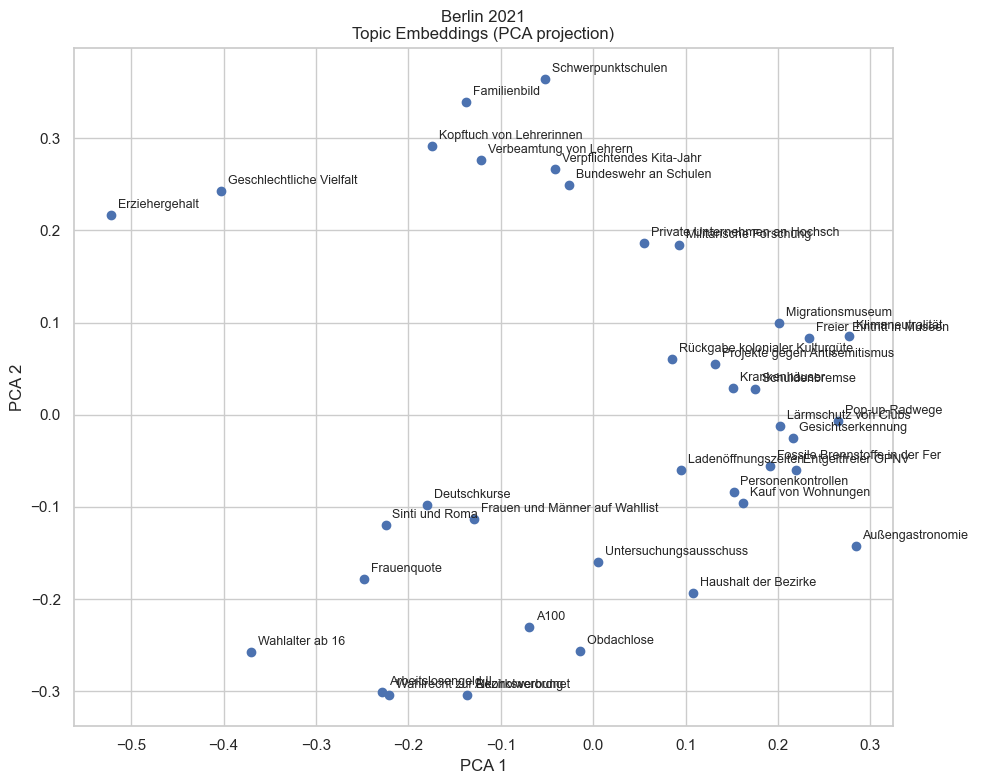

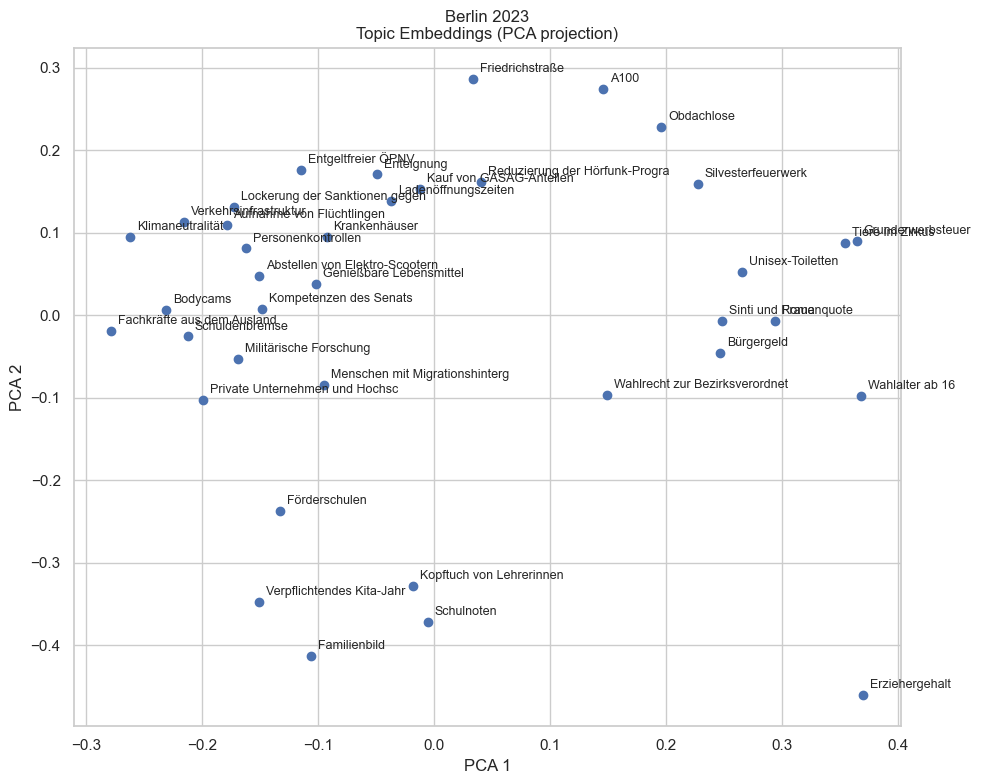

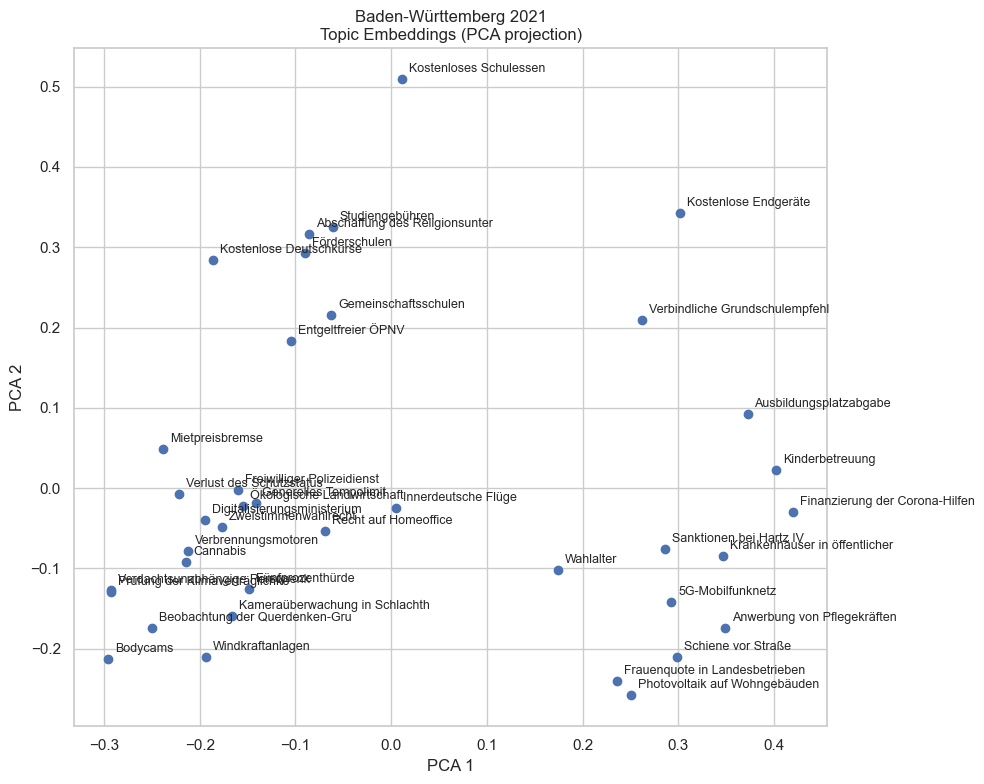

In [ ]:
'''
plotting.plot_topic_embeddings(embeddings_berlin_2021, "Berlin 2021")
plotting.plot_topic_embeddings(embeddings_berlin_2023, "Berlin 2023")
plotting.plot_topic_embeddings(embeddings_bawue_2021, "Baden-Württemberg 2021")
'''

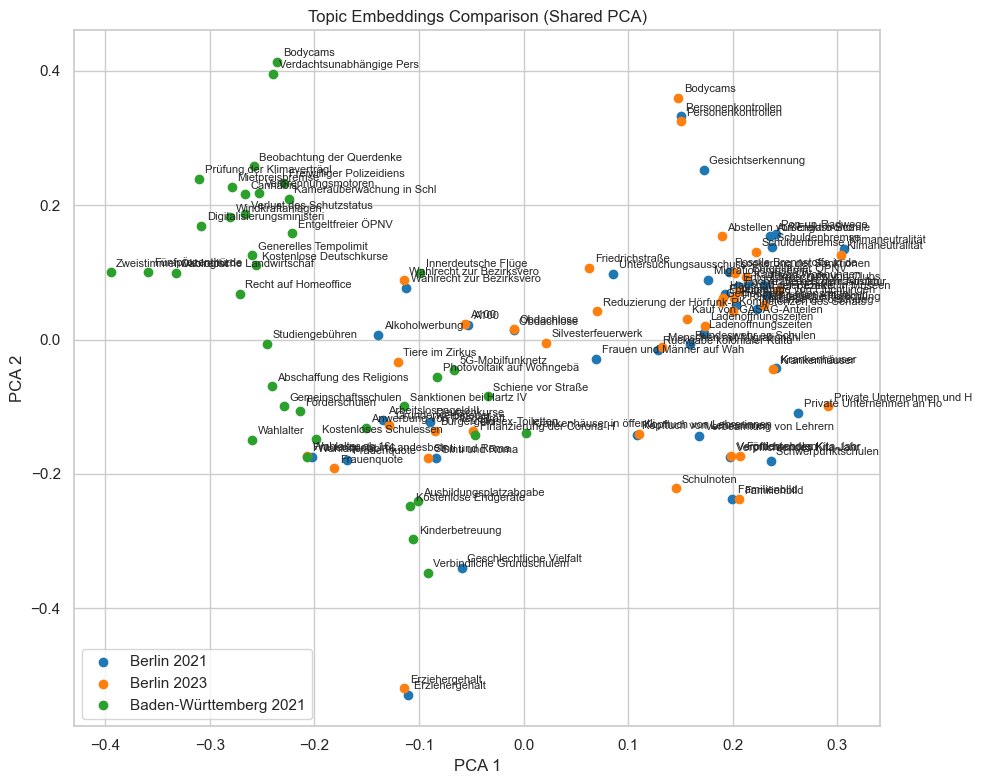

In [ ]:
plotting.plot_multiple_topic_embeddings(
    [embeddings_berlin_2021, embeddings_berlin_2023, embeddings_bawue_2021, embeddings_brandenburg_2024],
    names=["Berlin 2021", "Berlin 2023", "Baden-Württemberg 2021", "Brandenburg 2024"]
)
